In [1]:
import sys
sys.path.append('/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF')

import os

from loadData import data_pipe
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import SequentialLR, StepLR, LambdaLR
from thop import profile, clever_format

import cv2
import csv
import time
import json
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
# plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe, data_reader
from loadData.split_data import HyperX2, HyperX3
from loadData.dataAugmentation import DataAugmentation

from models import vision_transformer, CNNBase, vision_transformer_dino
from models import automaticWeightedLoss, modules
from models.MS2CANet import pymodel
from models import get_model_config
# from models.Morphs import morphFormer2
from utils import trainer, tester, infoNCE, tools, focalLoss
from utils import distillation, CELoss, visulization

# from utils import orthogonalLoss
from sklearn.feature_selection import f_regression, mutual_info_regression

using GPU 1


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.7.1+cu126 with CUDA 1208 (you have 2.8.0+cu128)
    Python  3.9.23 (you have 3.10.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
args = opt.get_args()
# args.dataset_name = "IndianPines"
# args.dataset_name = "PaviaU"
args.dataset_name = "Houston_2013"
# args.dataset_name = "Houston_2018"

# args.backbone = "MiViT"
args.backbone = "resNet2"
# args.backbone = "morphFormer2"
# args.backbone = "vit_dino_s"
# args.backbone = "vit_dino_b"
# args.backbone = "MS2CANet"
get_model_config(args)


# args.split_type = "disjoint"
args.split_type = "ratio"
print("args.backbone", args.backbone)

args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-08-resNet2_Houston_2013"
# args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-35-vit_dino_s_Houston_2013"

args.backbone resNet2


In [3]:
args.threshold = 1

In [4]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt, GT = data_pipe.get_data(args)
band1 = img1.shape[2]
band2 = img2.shape[2]
args.min = str(np.min(img1))
args.max = str(np.max(img1))
print("img1", img1.shape, "img2", img2.shape, band1, band2, args.min, args.max)
print("train_gt", train_gt.shape, \
		"test_gt", test_gt.shape, \
		"data_gt", data_gt.shape, \
		"GT", GT.shape)

img1 = img1[:, 1220:1683, :]
img2 = img2[:, 1220:1683, :]
# label = data_gt[:, 1220:1683]
print("after padding img.shape, gt.shape", img1.shape, img2.shape) 


img1 = cv2.resize(img1, (img1.shape[1]*3, img1.shape[0]*3), cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (img2.shape[1]*3, img2.shape[0]*3), cv2.INTER_LINEAR)
img2 = img2[:, :, np.newaxis]
print("resized img.shape, gt.shape", img1.shape, img2.shape) 

pca is used
img1 (363, 1919, 15) img2 (363, 1919, 1) 15 1 -61.004364 69.50995
train_gt (363, 1919) test_gt (363, 1919) data_gt (363, 1919) GT (349, 1905)
after padding img.shape, gt.shape (363, 463, 15) (363, 463, 1)
resized img.shape, gt.shape (1089, 1389, 15) (1089, 1389, 1)


In [5]:
# 整个传入到 GPU 中
modality_1_t = torch.tensor(img1).to(args.device)
modality_2_t  = torch.tensor(img2).to(args.device)
# label_t  = torch.tensor(label).to(args.device)

modality_1_g = modality_1_t.permute(2, 0, 1).unsqueeze(0)
modality_2_g = modality_2_t.permute(2, 0, 1).unsqueeze(0)
print("Size", modality_1_g.shape, modality_2_g.shape)

Size torch.Size([1, 15, 1089, 1389]) torch.Size([1, 1, 1089, 1389])


In [6]:
if args.backbone == "resNet2":
    encoder = CNNBase.Model_base(channell=band1, channel2=band2).to(args.device)
    args.feature_dim = 512
    # args.feature_dim = 2048

elif args.backbone == "vit_dino_s":
    selected_layers = [0, 2, 5, 7]  # 从 dinov2 中选择的层
    encoder = vision_transformer_dino.Vit_base(band1, band2, args.randomCrop, selected_layers=selected_layers).to(args.device)
    args.feature_dim = 384

elif args.backbone == "vit_dino_b":
    selected_layers = [0, 2, 5, 7]  # 从 dinov2 中选择的层
    encoder = vision_transformer_dino.vit_selected_base(band1, band2, args.randomCrop, selected_layers=selected_layers).to(args.device)
    args.feature_dim = 768

In [7]:
from pathlib import Path
args.resume = Path(os.path.join(args.result_dir, "test_loss.pth"))

if args.resume.is_file():
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-08-resNet2_Houston_2013/test_loss.pth epoch 45


In [8]:
def visualize_single_scale(feat_a, patch_h, patch_w, background_threshold=1):
    """
    feat_a: [1, C, H, W]
    """
    # print("feat_a shape", feat_a.shape)
    
    B, C, H, W = feat_a.shape

    # 提取 flow 和 conf
    pca = PCA(n_components=3)
    scaler = MinMaxScaler(clip=True)

    patch_features = feat_a.permute(0, 2, 3 ,1).reshape(B*patch_h*patch_w, -1).cpu().detach().numpy()
    # print("patch_features", patch_features.shape) # 256, 768

    # First fit to seperate background and foreground
    pca.fit(patch_features)
    pca_features = pca.transform(patch_features)

    # MinMax Scaling
    scaler.fit(pca_features)
    pca_features = scaler.transform(pca_features)

    # Sometimes the predictions might come out slightly changed
    # you can play with the threshold to improve the outcome.
    pca_background = pca_features[:, 0] > background_threshold
    pca_foreground = ~pca_background

    # Second fit for the object
    pca.fit(patch_features[pca_foreground])
    pca_features_rem = pca.transform(patch_features[pca_foreground])

    scaler.fit(pca_features_rem)
    pca_features_rem = scaler.transform(pca_features_rem)

    pca_features_rgb = np.zeros((B * patch_h * patch_w, 3))
    pca_features_rgb[pca_background] = 0
    pca_features_rgb[pca_foreground] = pca_features_rem
    pca_features_rgb = pca_features_rgb.reshape(B, patch_h, patch_w, 3)
    print("pca_features_rgb", pca_features_rgb.shape) # B, 16, 16, 3

    plt.imshow(pca_features_rgb[0])
    plt.title(f"Original image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
v1, v2, v3 = encoder.get_visulization(modality_1_g, modality_2_g)
print("v1, v2, v3", v1.shape, v2.shape, v3.shape)

v1, v2, v3 torch.Size([1, 512, 137, 174]) torch.Size([1, 512, 137, 174]) torch.Size([1, 512, 137, 174])


pca_features_rgb (1, 137, 174, 3)


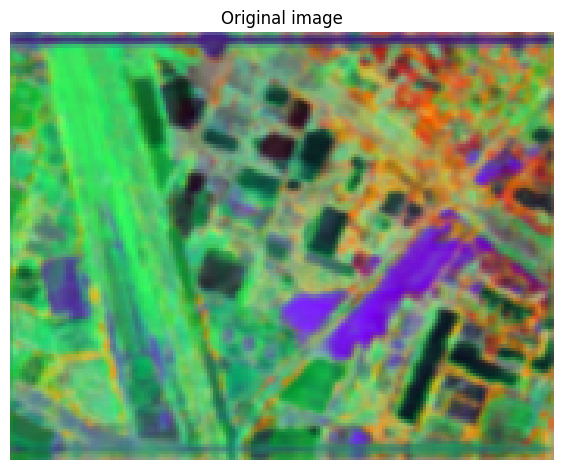

pca_features_rgb (1, 137, 174, 3)


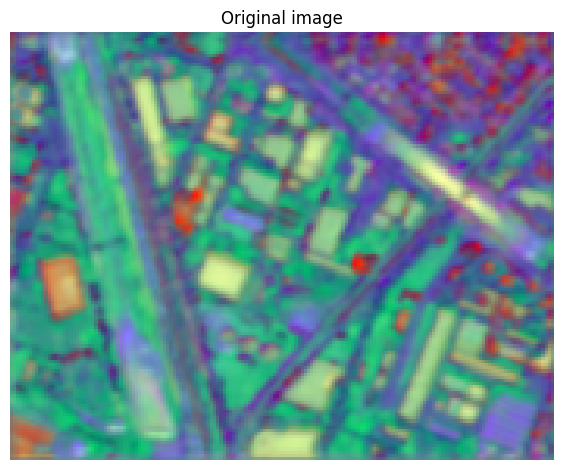

pca_features_rgb (1, 137, 174, 3)


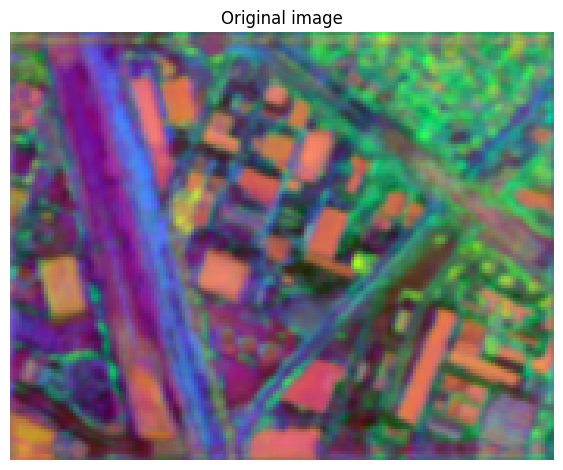

In [11]:
visualize_single_scale(v1, 137, 174, background_threshold=args.threshold)
visualize_single_scale(v2, 137, 174, background_threshold=args.threshold)
visualize_single_scale(v3, 137, 174, background_threshold=args.threshold)